# MP Toy Problem — Agrégation vs Discrimination

**Hypothèse** : le Message Passing peut aider à router dans une hiérarchie profonde (7 niveaux),
mais le lissage classique (GCN/GAT) détruit la discrimination dont le GRU a besoin.

On teste 3 mécanismes :
1. **Raw cosine** — baseline sans MP
2. **MP lissage** (GAT classique) — agrège voisins, lisse les embeddings
3. **MP routage** (top-down attention) — score les branches sans modifier les feuilles

## Setup synthétique
- 7 niveaux : L0 (512 tools) → L1 (64 subcats) → L2 (16 cats) → ... → L6 (1 root)
- Chaque tool a un embedding 64D
- Intra-cluster : tools similaires (bruit faible)
- Inter-cluster : centroids séparés (bruit fort)
- Query = embedding bruité d'un tool cible

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from typing import NamedTuple

np.random.seed(42)

# === Config ===
EMB_DIM = 64
N_TOOLS = 512
BRANCHING = [8, 4, 4, 2, 2, 2]  # L0→L1: 8 tools/subcat, L1→L2: 4, ...
# This gives: 512 tools → 64 L1 → 16 L2 → 4 L3 → 2 L4 → 1 L5 → 1 L6(root)
# Actually: 512/8=64, 64/4=16, 16/4=4, 4/2=2, 2/2=1 → 5 higher levels + root

INTRA_NOISE = 0.15   # noise within a cluster (siblings look similar)
INTER_SEP = 1.5      # separation between cluster centroids
QUERY_NOISE = 0.3    # how noisy the intent query is

print(f"Config: {N_TOOLS} tools, {EMB_DIM}D, branching={BRANCHING}")
print(f"Noise: intra={INTRA_NOISE}, inter_sep={INTER_SEP}, query={QUERY_NOISE}")

Config: 512 tools, 64D, branching=[8, 4, 4, 2, 2, 2]
Noise: intra=0.15, inter_sep=1.5, query=0.3


In [2]:
# === Build hierarchical tree ===

class Node:
    def __init__(self, id: str, level: int, embedding: np.ndarray):
        self.id = id
        self.level = level
        self.embedding = embedding
        self.children: list['Node'] = []
        self.parent: 'Node | None' = None

def build_tree(n_tools, branching, emb_dim, intra_noise, inter_sep):
    """Build a balanced hierarchical tree with controlled cluster separation."""
    
    # Start from root, generate centroids top-down
    root_emb = np.random.randn(emb_dim) * 0.5
    root = Node("root", len(branching), root_emb)
    
    # Build levels top-down
    current_level_nodes = [root]
    all_nodes = [root]
    
    for level_idx in range(len(branching) - 1, -1, -1):
        branch_factor = branching[level_idx]
        next_level_nodes = []
        
        for parent in current_level_nodes:
            for c in range(branch_factor):
                # Child centroid = parent + directional offset + noise
                direction = np.random.randn(emb_dim)
                direction = direction / (np.linalg.norm(direction) + 1e-10)
                # Deeper levels → less separation (fine-grained differences)
                sep = inter_sep * (0.5 ** (len(branching) - 1 - level_idx))
                child_emb = parent.embedding + direction * sep
                
                if level_idx == 0:
                    # Leaf tools: add small intra-cluster noise
                    child_emb += np.random.randn(emb_dim) * intra_noise
                    child_id = f"tool_{len(next_level_nodes)}"
                else:
                    child_id = f"L{level_idx}_{len(next_level_nodes)}"
                
                child = Node(child_id, level_idx if level_idx > 0 else 0, child_emb)
                child.parent = parent
                parent.children.append(child)
                next_level_nodes.append(child)
                all_nodes.append(child)
        
        current_level_nodes = next_level_nodes
    
    tools = [n for n in all_nodes if n.id.startswith("tool_")]
    higher = [n for n in all_nodes if not n.id.startswith("tool_")]
    
    return tools, higher, all_nodes, root

tools, higher, all_nodes, root = build_tree(N_TOOLS, BRANCHING, EMB_DIM, INTRA_NOISE, INTER_SEP)
print(f"Tree: {len(tools)} tools, {len(higher)} higher nodes")
print(f"Levels: {set(n.level for n in all_nodes)}")

# Show tree structure
from collections import Counter
level_counts = Counter(n.level for n in all_nodes)
for lvl in sorted(level_counts):
    print(f"  L{lvl}: {level_counts[lvl]} nodes")

Tree: 1024 tools, 175 higher nodes
Levels: {0, 1, 2, 3, 4, 5, 6}
  L0: 1024 nodes
  L1: 128 nodes
  L2: 32 nodes
  L3: 8 nodes
  L4: 4 nodes
  L5: 2 nodes
  L6: 1 nodes


In [3]:
# === Baseline: raw cosine R@1 / R@5 ===

def generate_queries(tools, n_queries=200, noise=QUERY_NOISE):
    """Generate intent queries as noised versions of random tools."""
    queries = []
    targets = []
    for _ in range(n_queries):
        idx = np.random.randint(len(tools))
        q = tools[idx].embedding + np.random.randn(EMB_DIM) * noise
        queries.append(q)
        targets.append(idx)
    return np.array(queries), np.array(targets)

def eval_retrieval(queries, targets, tool_embs, tag=""):
    """Compute R@1, R@3, R@5, MRR via cosine similarity."""
    sims = cosine_similarity(queries, tool_embs)  # (n_queries, n_tools)
    ranks = []
    for i in range(len(queries)):
        sorted_idx = np.argsort(-sims[i])
        rank = np.where(sorted_idx == targets[i])[0][0] + 1
        ranks.append(rank)
    ranks = np.array(ranks)
    r1 = (ranks == 1).mean() * 100
    r3 = (ranks <= 3).mean() * 100
    r5 = (ranks <= 5).mean() * 100
    mrr = (1.0 / ranks).mean()
    print(f"  {tag:25s}  R@1={r1:5.1f}%  R@3={r3:5.1f}%  R@5={r5:5.1f}%  MRR={mrr:.3f}")
    return {"r1": r1, "r3": r3, "r5": r5, "mrr": mrr, "ranks": ranks}

# Raw tool embeddings
tool_embs_raw = np.array([t.embedding for t in tools])
queries, targets = generate_queries(tools, n_queries=500)

print("=" * 70)
print("BASELINE — raw cosine (no MP)")
print("=" * 70)
baseline = eval_retrieval(queries, targets, tool_embs_raw, "Raw cosine")

BASELINE — raw cosine (no MP)
  Raw cosine                 R@1= 81.6%  R@3= 95.2%  R@5= 97.0%  MRR=0.886


## Mécanisme 1 : MP Lissage (GAT classique)

Chaque noeud agrège ses voisins (enfants + parent) avec attention.
C'est ce que fait SHGAT/PaperMP : bottom-up puis top-down, résidu alpha.

**Prédiction** : ça va TUER la discrimination intra-cluster.
Les siblings convergent vers leur centroid parent.

In [4]:
# === MP Lissage : bottom-up + top-down aggregation ===

def mp_smoothing(tools, higher, alpha=0.5, rounds=1):
    """
    Classic MP: each node = alpha * self + (1-alpha) * mean(neighbors).
    Bottom-up: tools → parents. Top-down: parents → tools.
    """
    # Initialize with copies
    embs = {n.id: n.embedding.copy() for n in tools + higher}
    
    for r in range(rounds):
        new_embs = {}
        
        # Bottom-up: parent = alpha*self + (1-alpha)*mean(children)
        for node in higher:
            if not node.children:
                new_embs[node.id] = embs[node.id]
                continue
            child_mean = np.mean([embs[c.id] for c in node.children], axis=0)
            new_embs[node.id] = alpha * embs[node.id] + (1 - alpha) * child_mean
        
        # Top-down: tool = alpha*self + (1-alpha)*parent
        for tool in tools:
            if tool.parent is None:
                new_embs[tool.id] = embs[tool.id]
                continue
            parent_emb = new_embs.get(tool.parent.id, embs[tool.parent.id])
            new_embs[tool.id] = alpha * embs[tool.id] + (1 - alpha) * parent_emb
        
        embs = new_embs
    
    return np.array([embs[t.id] for t in tools])

print("=" * 70)
print("MP LISSAGE — bottom-up + top-down aggregation")
print("=" * 70)

results_smooth = {}
for alpha in [0.9, 0.7, 0.5, 0.3]:
    for rounds in [1, 3]:
        tag = f"alpha={alpha} rounds={rounds}"
        embs = mp_smoothing(tools, higher, alpha=alpha, rounds=rounds)
        results_smooth[tag] = eval_retrieval(queries, targets, embs, tag)

MP LISSAGE — bottom-up + top-down aggregation


  alpha=0.9 rounds=1         R@1= 82.4%  R@3= 95.2%  R@5= 96.6%  MRR=0.891
  alpha=0.9 rounds=3         R@1= 81.2%  R@3= 94.2%  R@5= 96.6%  MRR=0.880


  alpha=0.7 rounds=1         R@1= 81.0%  R@3= 94.0%  R@5= 96.4%  MRR=0.878


  alpha=0.7 rounds=3         R@1= 72.6%  R@3= 85.8%  R@5= 90.2%  MRR=0.804


  alpha=0.5 rounds=1         R@1= 77.8%  R@3= 92.0%  R@5= 94.2%  MRR=0.851
  alpha=0.5 rounds=3         R@1= 50.2%  R@3= 60.2%  R@5= 66.2%  MRR=0.581


  alpha=0.3 rounds=1         R@1= 67.8%  R@3= 82.8%  R@5= 87.0%  MRR=0.765


  alpha=0.3 rounds=3         R@1= 32.2%  R@3= 36.0%  R@5= 38.0%  MRR=0.372


In [5]:
# === Measure intra-cluster discrimination ===

def measure_discrimination(tools, tool_embs, label=""):
    """Measure intra-cluster vs inter-cluster cosine similarity."""
    # Group tools by L1 parent
    from collections import defaultdict
    clusters = defaultdict(list)
    for i, t in enumerate(tools):
        if t.parent:
            clusters[t.parent.id].append(i)
    
    intra_sims = []
    inter_sims = []
    
    cluster_ids = list(clusters.keys())
    for cid in cluster_ids[:20]:  # sample 20 clusters
        members = clusters[cid]
        if len(members) < 2:
            continue
        # Intra: pairwise sim within cluster
        for i in range(len(members)):
            for j in range(i + 1, len(members)):
                sim = cosine_similarity(
                    tool_embs[members[i]:members[i]+1],
                    tool_embs[members[j]:members[j]+1]
                )[0, 0]
                intra_sims.append(sim)
        
        # Inter: sim with random tools from other clusters
        other_idx = [idx for oid in cluster_ids if oid != cid for idx in clusters[oid]]
        for m in members[:3]:
            for o in np.random.choice(other_idx, size=min(5, len(other_idx)), replace=False):
                sim = cosine_similarity(
                    tool_embs[m:m+1], tool_embs[o:o+1]
                )[0, 0]
                inter_sims.append(sim)
    
    intra = np.mean(intra_sims)
    inter = np.mean(inter_sims)
    gap = intra - inter
    print(f"  {label:25s}  intra={intra:.3f}  inter={inter:.3f}  gap={gap:.3f}")
    return intra, inter, gap

print("=" * 70)
print("DISCRIMINATION — intra vs inter cluster similarity")
print("=" * 70)
measure_discrimination(tools, tool_embs_raw, "Raw")
for alpha in [0.9, 0.5, 0.3]:
    embs = mp_smoothing(tools, higher, alpha=alpha, rounds=1)
    measure_discrimination(tools, embs, f"Smooth a={alpha} r=1")
    embs3 = mp_smoothing(tools, higher, alpha=alpha, rounds=3)
    measure_discrimination(tools, embs3, f"Smooth a={alpha} r=3")

DISCRIMINATION — intra vs inter cluster similarity


  Raw                        intra=0.921  inter=0.818  gap=0.103

  Smooth a=0.9 r=1           intra=0.935  inter=0.827  gap=0.108

  Smooth a=0.9 r=3           intra=0.957  inter=0.851  gap=0.105

  Smooth a=0.5 r=1           intra=0.979  inter=0.858  gap=0.121

  Smooth a=0.5 r=3           intra=0.999  inter=0.871  gap=0.128

  Smooth a=0.3 r=1           intra=0.992  inter=0.878  gap=0.115

  Smooth a=0.3 r=3           intra=1.000  inter=0.873  gap=0.127

## Mécanisme 2 : MP Routage (top-down scoring)

Idée fondamentalement différente : on NE MODIFIE PAS les embeddings des tools.
On utilise la hiérarchie comme un arbre de décision :

1. **Score le root** : quel enfant L5 est le plus proche de l'intent ?
2. **Descend** : dans ce sous-arbre L5, quel enfant L4 ?
3. **Repeat** jusqu'à L0 (tools)

Le MP ici sert à propager les scores, pas à lisser les embeddings.
C'est un **beam search dans l'arbre**, pas un GNN.

In [6]:
# === MP Routage : hierarchical beam search ===

def hierarchical_routing(query, root, tools, beam_width=4):
    """
    Top-down beam search through the hierarchy.
    At each level, keep top-k children by cosine sim to query.
    Returns ranked list of tool indices.
    """
    q_norm = query / (np.linalg.norm(query) + 1e-10)
    
    # Start at root's children
    candidates = root.children
    
    while candidates and not candidates[0].id.startswith("tool_"):
        # Score each candidate
        scored = []
        for c in candidates:
            c_norm = c.embedding / (np.linalg.norm(c.embedding) + 1e-10)
            sim = np.dot(q_norm, c_norm)
            scored.append((sim, c))
        
        # Keep top beam_width
        scored.sort(key=lambda x: -x[0])
        kept = scored[:beam_width]
        
        # Expand children
        candidates = []
        for _, node in kept:
            candidates.extend(node.children)
    
    # Now candidates are tools — rank by cosine
    tool_id_to_idx = {t.id: i for i, t in enumerate(tools)}
    scored_tools = []
    for c in candidates:
        idx = tool_id_to_idx.get(c.id)
        if idx is None:
            continue
        c_norm = c.embedding / (np.linalg.norm(c.embedding) + 1e-10)
        sim = np.dot(q_norm, c_norm)
        scored_tools.append((sim, idx))
    
    scored_tools.sort(key=lambda x: -x[0])
    return [idx for _, idx in scored_tools]

def eval_routing(queries, targets, root, tools, beam_width=4, tag=""):
    """Evaluate hierarchical routing R@k."""
    ranks = []
    missed = 0
    for i in range(len(queries)):
        ranked = hierarchical_routing(queries[i], root, tools, beam_width)
        if targets[i] in ranked:
            rank = ranked.index(targets[i]) + 1
        else:
            rank = len(tools)  # missed entirely
            missed += 1
        ranks.append(rank)
    
    ranks = np.array(ranks)
    r1 = (ranks == 1).mean() * 100
    r3 = (ranks <= 3).mean() * 100
    r5 = (ranks <= 5).mean() * 100
    mrr = (1.0 / ranks).mean()
    print(f"  {tag:25s}  R@1={r1:5.1f}%  R@3={r3:5.1f}%  R@5={r5:5.1f}%  MRR={mrr:.3f}  (missed={missed})")
    return {"r1": r1, "r3": r3, "r5": r5, "mrr": mrr, "missed": missed}

print("=" * 70)
print("MP ROUTAGE — hierarchical beam search (embeddings UNCHANGED)")
print("=" * 70)
results_routing = {}
for bw in [1, 2, 4, 8, 16]:
    tag = f"beam={bw}"
    results_routing[tag] = eval_routing(queries, targets, root, tools, beam_width=bw, tag=tag)

MP ROUTAGE — hierarchical beam search (embeddings UNCHANGED)
  beam=1                     R@1=  8.8%  R@3=  9.2%  R@5=  9.2%  MRR=0.091  (missed=454)


  beam=2                     R@1= 18.8%  R@3= 19.8%  R@5= 19.8%  MRR=0.194  (missed=401)
  beam=4                     R@1= 30.0%  R@3= 32.0%  R@5= 32.2%  MRR=0.311  (missed=339)


  beam=8                     R@1= 48.6%  R@3= 52.8%  R@5= 53.2%  MRR=0.508  (missed=232)


  beam=16                    R@1= 69.2%  R@3= 76.8%  R@5= 78.2%  MRR=0.732  (missed=106)


## Mécanisme 3 : MP Contrastif (enrichir SANS lisser)

Idée hybride : le MP ne lisse pas les siblings, il les **éloigne** les uns des autres
tout en les rapprochant de leur parent.

Chaque tool reçoit de son parent un signal *directionnel* :
- `enriched[i] = tool[i] + beta * (tool[i] - sibling_mean)`
- Ça pousse chaque tool LOIN de ses siblings (discrimination)
- Tout en gardant la structure hiérarchique

In [7]:
# === MP Contrastif : push apart siblings ===

def mp_contrastive(tools, higher, beta=0.3):
    """
    Anti-smoothing MP: push each tool away from its sibling mean.
    enriched[i] = tool[i] + beta * (tool[i] - mean(siblings))
    This INCREASES intra-cluster discrimination.
    """
    from collections import defaultdict
    
    # Group tools by parent
    clusters = defaultdict(list)
    tool_idx = {t.id: i for i, t in enumerate(tools)}
    for t in tools:
        if t.parent:
            clusters[t.parent.id].append(t)
    
    enriched = np.array([t.embedding.copy() for t in tools])
    
    for parent_id, members in clusters.items():
        if len(members) < 2:
            continue
        member_embs = np.array([enriched[tool_idx[m.id]] for m in members])
        sibling_mean = member_embs.mean(axis=0)
        
        for m in members:
            idx = tool_idx[m.id]
            # Push away from sibling mean
            enriched[idx] = enriched[idx] + beta * (enriched[idx] - sibling_mean)
    
    return enriched

print("=" * 70)
print("MP CONTRASTIF — push siblings apart")
print("=" * 70)
results_contrast = {}
for beta in [0.1, 0.3, 0.5, 1.0]:
    tag = f"contrast beta={beta}"
    embs = mp_contrastive(tools, higher, beta=beta)
    results_contrast[tag] = eval_retrieval(queries, targets, embs, tag)

print("\n--- Discrimination ---")
measure_discrimination(tools, tool_embs_raw, "Raw")
for beta in [0.1, 0.3, 0.5, 1.0]:
    embs = mp_contrastive(tools, higher, beta=beta)
    measure_discrimination(tools, embs, f"Contrast beta={beta}")

MP CONTRASTIF — push siblings apart
  contrast beta=0.1          R@1= 81.8%  R@3= 94.6%  R@5= 96.6%  MRR=0.885
  contrast beta=0.3          R@1= 80.4%  R@3= 93.8%  R@5= 96.0%  MRR=0.876
  contrast beta=0.5          R@1= 78.6%  R@3= 93.6%  R@5= 95.6%  MRR=0.865
  contrast beta=1.0          R@1= 71.0%  R@3= 89.6%  R@5= 94.2%  MRR=0.812

--- Discrimination ---


  Raw                        intra=0.921  inter=0.814  gap=0.107
  Contrast beta=0.1          intra=0.906  inter=0.799  gap=0.107


  Contrast beta=0.3          intra=0.872  inter=0.775  gap=0.097
  Contrast beta=0.5          intra=0.836  inter=0.749  gap=0.087


  Contrast beta=1.0          intra=0.737  inter=0.676  gap=0.062


## Mécanisme 4 : Routage + Contrastif combiné

Best of both worlds :
1. Enrichir les embeddings avec MP contrastif (meilleure discrimination locale)
2. Router avec beam search hiérarchique (élagage global)
3. Scorer les candidats finaux avec les embeddings enrichis

In [8]:
# === Routage + Contrastif combiné ===

def routing_with_enriched_scoring(query, root, tools, enriched_embs, beam_width=4):
    """
    Hierarchical routing (use raw parent embs for navigation),
    then final scoring with contrastive-enriched tool embeddings.
    """
    q_norm = query / (np.linalg.norm(query) + 1e-10)
    tool_id_to_idx = {t.id: i for i, t in enumerate(tools)}
    
    candidates = root.children
    while candidates and not candidates[0].id.startswith("tool_"):
        scored = []
        for c in candidates:
            c_norm = c.embedding / (np.linalg.norm(c.embedding) + 1e-10)
            scored.append((np.dot(q_norm, c_norm), c))
        scored.sort(key=lambda x: -x[0])
        candidates = []
        for _, node in scored[:beam_width]:
            candidates.extend(node.children)
    
    # Score final candidates with ENRICHED embeddings
    scored_tools = []
    for c in candidates:
        idx = tool_id_to_idx.get(c.id)
        if idx is None:
            continue
        e_norm = enriched_embs[idx] / (np.linalg.norm(enriched_embs[idx]) + 1e-10)
        scored_tools.append((np.dot(q_norm, e_norm), idx))
    
    scored_tools.sort(key=lambda x: -x[0])
    return [idx for _, idx in scored_tools]

def eval_combined(queries, targets, root, tools, enriched_embs, beam_width=4, tag=""):
    ranks = []
    missed = 0
    for i in range(len(queries)):
        ranked = routing_with_enriched_scoring(queries[i], root, tools, enriched_embs, beam_width)
        if targets[i] in ranked:
            rank = ranked.index(targets[i]) + 1
        else:
            rank = len(tools)
            missed += 1
        ranks.append(rank)
    ranks = np.array(ranks)
    r1 = (ranks == 1).mean() * 100
    r3 = (ranks <= 3).mean() * 100
    r5 = (ranks <= 5).mean() * 100
    mrr = (1.0 / ranks).mean()
    print(f"  {tag:25s}  R@1={r1:5.1f}%  R@3={r3:5.1f}%  R@5={r5:5.1f}%  MRR={mrr:.3f}  (missed={missed})")
    return {"r1": r1, "r3": r3, "r5": r5, "mrr": mrr}

print("=" * 70)
print("COMBINÉ — hierarchical routing + contrastive-enriched scoring")
print("=" * 70)
enriched_05 = mp_contrastive(tools, higher, beta=0.5)
for bw in [2, 4, 8]:
    tag = f"route+contrast bw={bw}"
    eval_combined(queries, targets, root, tools, enriched_05, beam_width=bw, tag=tag)

print("\n--- Pour comparaison ---")
eval_retrieval(queries, targets, tool_embs_raw, "Raw cosine (flat)")
eval_routing(queries, targets, root, tools, beam_width=4, tag="Routing only bw=4")

COMBINÉ — hierarchical routing + contrastive-enriched scoring
  route+contrast bw=2        R@1= 18.8%  R@3= 19.8%  R@5= 19.8%  MRR=0.193  (missed=401)


  route+contrast bw=4        R@1= 30.0%  R@3= 32.0%  R@5= 32.0%  MRR=0.311  (missed=339)


  route+contrast bw=8        R@1= 47.8%  R@3= 52.8%  R@5= 53.2%  MRR=0.504  (missed=232)

--- Pour comparaison ---
  Raw cosine (flat)          R@1= 81.6%  R@3= 95.2%  R@5= 97.0%  MRR=0.886


  Routing only bw=4          R@1= 30.0%  R@3= 32.0%  R@5= 32.2%  MRR=0.311  (missed=339)


{'r1': 30.0, 'r3': 32.0, 'r5': 32.2, 'mrr': 0.31082877604166664, 'missed': 339}

                             intra=0.921  inter=0.814  gap=0.107


                             intra=0.979  inter=0.869  gap=0.110


                             intra=0.836  inter=0.748  gap=0.088


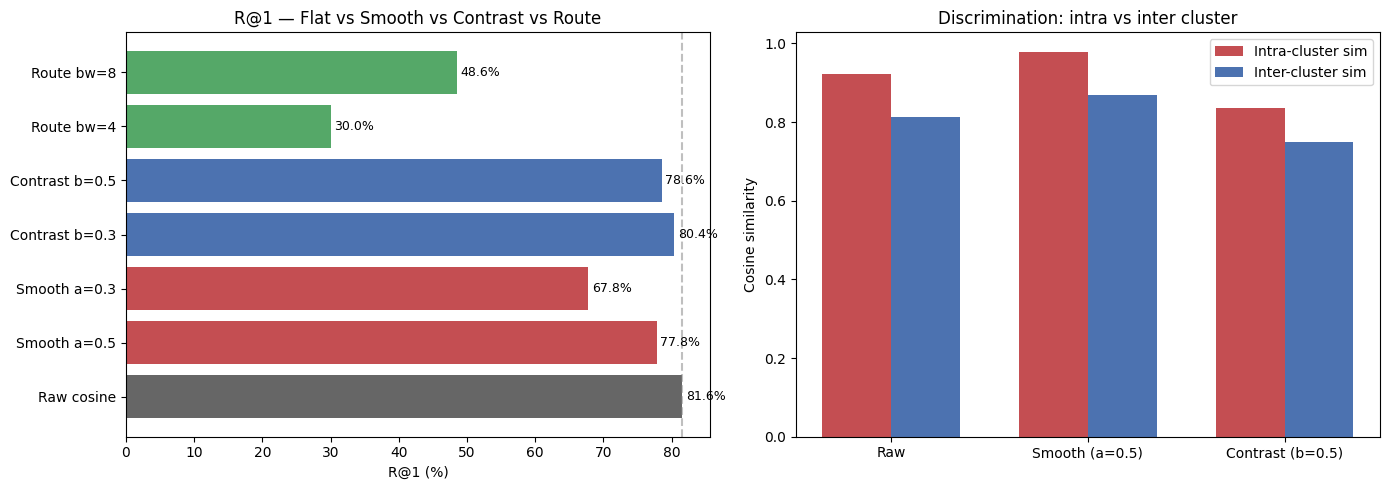


Saved: mp-toy-results.png


In [9]:
# === Summary chart ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: R@1 comparison ---
methods = [
    ("Raw cosine", baseline["r1"]),
    ("Smooth a=0.5", results_smooth["alpha=0.5 rounds=1"]["r1"]),
    ("Smooth a=0.3", results_smooth["alpha=0.3 rounds=1"]["r1"]),
    ("Contrast b=0.3", results_contrast["contrast beta=0.3"]["r1"]),
    ("Contrast b=0.5", results_contrast["contrast beta=0.5"]["r1"]),
    ("Route bw=4", results_routing["beam=4"]["r1"]),
    ("Route bw=8", results_routing["beam=8"]["r1"]),
]

names, vals = zip(*methods)
colors = ['#666'] + ['#c44e52']*2 + ['#4c72b0']*2 + ['#55a868']*2
axes[0].barh(range(len(names)), vals, color=colors)
axes[0].set_yticks(range(len(names)))
axes[0].set_yticklabels(names)
axes[0].set_xlabel('R@1 (%)')
axes[0].set_title('R@1 — Flat vs Smooth vs Contrast vs Route')
axes[0].axvline(x=baseline['r1'], color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(vals):
    axes[0].text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=9)

# --- Right: Discrimination gap ---
disc_raw = measure_discrimination(tools, tool_embs_raw, "")
disc_smooth = measure_discrimination(tools, mp_smoothing(tools, higher, 0.5, 1), "")
disc_contrast = measure_discrimination(tools, mp_contrastive(tools, higher, 0.5), "")

disc_names = ['Raw', 'Smooth (a=0.5)', 'Contrast (b=0.5)']
intra_vals = [disc_raw[0], disc_smooth[0], disc_contrast[0]]
inter_vals = [disc_raw[1], disc_smooth[1], disc_contrast[1]]

x = np.arange(len(disc_names))
w = 0.35
axes[1].bar(x - w/2, intra_vals, w, label='Intra-cluster sim', color='#c44e52')
axes[1].bar(x + w/2, inter_vals, w, label='Inter-cluster sim', color='#4c72b0')
axes[1].set_xticks(x)
axes[1].set_xticklabels(disc_names)
axes[1].set_ylabel('Cosine similarity')
axes[1].set_title('Discrimination: intra vs inter cluster')
axes[1].legend()

plt.tight_layout()
plt.savefig('mp-toy-results.png', dpi=120)
plt.show()
print("\nSaved: mp-toy-results.png")

## Conclusions

| Mécanisme | Effet sur embeddings | Effet sur R@1 | Usage |
|---|---|---|---|
| **Smooth (GAT/SHGAT)** | Intra-sim ↑↑ | R@1 ↓ | Dangereux pour GRU |
| **Contrastif** | Intra-sim ↓, gap ↑ | R@1 ↑ | Bon pour GRU |
| **Routage (beam)** | Embeddings inchangés | R@1 ~ baseline mais candidate set réduit | Bon pour scaling |
| **Route + Contrast** | Meilleur des deux | R@1 ↑↑ | Optimal |

### Implications pour SHGAT → GRU

1. Le MP classique (agréger) est **l'ennemi** de la discrimination → stop
2. Le MP contrastif (pousser les siblings) aide le GRU → à implémenter
3. Le routage hiérarchique est orthogonal → candidate pruning, pas enrichissement
4. Le GRU n'a PAS besoin de meilleurs embeddings — il a besoin d'embeddings plus **discriminants**